In [2]:
import os
import sys
import time
import math
import astropy
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from scipy import interpolate
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.table import Column
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm
from astropy.coordinates import Angle
from astropy import units as u
from matplotlib.colors import Normalize
from scipy.interpolate import RegularGridInterpolator

In [4]:
def getDataFromFits(imageName=None):
    w      = WCS(imageName, naxis=2)
    hdu    = fits.open(imageName)
    header = hdu[0].header
    data1  = hdu[0].data
    hdu.close()
    data   = np.squeeze(data1)
    return data, header, w

In [6]:
# PV diagram along the best-fit trajectory
PVFn  = 'HOPS-182_PV_fitting.fits'

PVMap, PVHdr, wcsPV    = getDataFromFits(PVFn)

print(PVHdr)


rms = 1.8e-2


PVMap_new = np.full((len(PVMap), len(PVMap[0])), np.nan)
for i in range(len(PVMap)):
    for j in range(len(PVMap[0])):
        if PVMap[i][j] < 10*rms:
            PVMap_new[i][j] = rms * 1000
        else:
            PVMap_new[i][j] = PVMap[i][j] * 1000

sub_map = PVMap_new[990:1080, :]

v_max = (PVHdr['CRVAL2']+(PVHdr['CDELT2']*(990.0-PVHdr['CRPIX2'])))/1000
v_min = (PVHdr['CRVAL2']+(PVHdr['CDELT2']*(1080.0-PVHdr['CRPIX2'])))/1000

print(v_max, v_min)

offset_min = PVHdr['CRVAL1']*3600
offset_max = (PVHdr['CRVAL1']+(PVHdr['CDELT1']*(len(PVMap[0])-PVHdr['CRPIX1'])))*3600

print(offset_max, offset_min)
print(sub_map.shape, len(sub_map[0]))



# PV diagram along the observed trajectory
PVFn1  = 'HOPS-182_PV_obs.fits'

PVMap1, PVHdr1, wcsPV1    = getDataFromFits(PVFn1)



rms1 = 1.8e-2


PVMap_new1 = np.full((len(PVMap1), len(PVMap1[0])), np.nan)
for i in range(len(PVMap1)):
    for j in range(len(PVMap1[0])):
        if PVMap1[i][j] < 10*rms1:
            PVMap_new1[i][j] = rms1 * 1000
        else:
            PVMap_new1[i][j] = PVMap1[i][j] * 1000

sub_map1 = PVMap_new1[990:1080, :]

v_max1 = (PVHdr1['CRVAL2']+(PVHdr1['CDELT2']*(990.0-PVHdr1['CRPIX2'])))/1000
v_min1 = (PVHdr1['CRVAL2']+(PVHdr1['CDELT2']*(1080.0-PVHdr1['CRPIX2'])))/1000

print(v_max1, v_min1)

offset_min1 = PVHdr1['CRVAL1']*3600
offset_max1 = (PVHdr1['CRVAL1']+(PVHdr1['CDELT1']*(len(PVMap1[0])-PVHdr1['CRPIX1'])))*3600

print(offset_max1, offset_min1)
print(sub_map1.shape, len(sub_map1[0]))

SIMPLE  =                    T /Standard FITS                                   BITPIX  =                  -32 /Floating point (32 bit)                         NAXIS   =                    2                                                  NAXIS1  =                   27                                                  NAXIS2  =                 1918                                                  EXTEND  =                    T                                                  BSCALE  =   1.000000000000E+00 /PHYSICAL = PIXEL*BSCALE + BZERO                 BZERO   =   0.000000000000E+00                                                  BTYPE   = 'Intensity'                                                           OBJECT  = '        '                                                            BUNIT   = '        '           /Brightness (pixel) unit                         PC1_1   =   1.000000000000E+00                                                  PC2_1   =   0.000000000000E+00          

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [8]:
x = np.arange(90)
y = np.arange(27)

interp_func = RegularGridInterpolator((x, y), sub_map, method='linear')

x_new = np.linspace(0, 89, 90)
y_new = np.linspace(0, 26, 90)

xx, yy = np.meshgrid(x_new, y_new, indexing='ij')

data_expanded = interp_func((xx, yy))

x_pixel_size = 0.16  # 1 pixel corresponds to 0.16 arcsec
x_total_pixels = 27  # total pixel number in x axis
x_start = 0  
x_end = x_total_pixels * x_pixel_size  
x_new = np.linspace(x_start, x_end, 90)

y_pixel_size = 4.168883139017E-2  # 1 pixel corresponds to 0.04168883139017 km/s
y_total_pixels = 90  # total pixel number in y axis
y_start = v_min  
y_end = y_start + (y_total_pixels - 1) * y_pixel_size  
y_new = np.linspace(y_start, y_end, 90)

data_min = np.nanmin(data_expanded)
data_max = np.nanmax(data_expanded)
print(data_min, data_max)
y_new_flipped = np.linspace(y_end, y_start, 90)



x1 = np.arange(90)
y1 = np.arange(29)

interp_func1 = RegularGridInterpolator((x1, y1), sub_map1, method='linear')

x_new1 = np.linspace(0, 89, 90)
y_new1 = np.linspace(0, 28, 90)

xx1, yy1 = np.meshgrid(x_new1, y_new1, indexing='ij')

data_expanded1 = interp_func1((xx1, yy1))

x_pixel_size1 = 0.16  
x_total_pixels1 = 29  
x_start1 = 0  
x_end1 = x_total_pixels1 * x_pixel_size1 
x_new1 = np.linspace(x_start1, x_end1, 90)

y_pixel_size1 = 4.168883139017E-2 
y_total_pixels1 = 90 
y_start1 = v_min1  
y_end1 = y_start1 + (y_total_pixels1 - 1) * y_pixel_size1  
y_new1 = np.linspace(y_start1, y_end1, 90)

data_min1 = np.nanmin(data_expanded1)
data_max1 = np.nanmax(data_expanded1)
print(data_min1, data_max1)
y_new_flipped1 = np.linspace(y_end1, y_start1, 90)

18.0 428.9502501487732
18.0 428.66286635398865


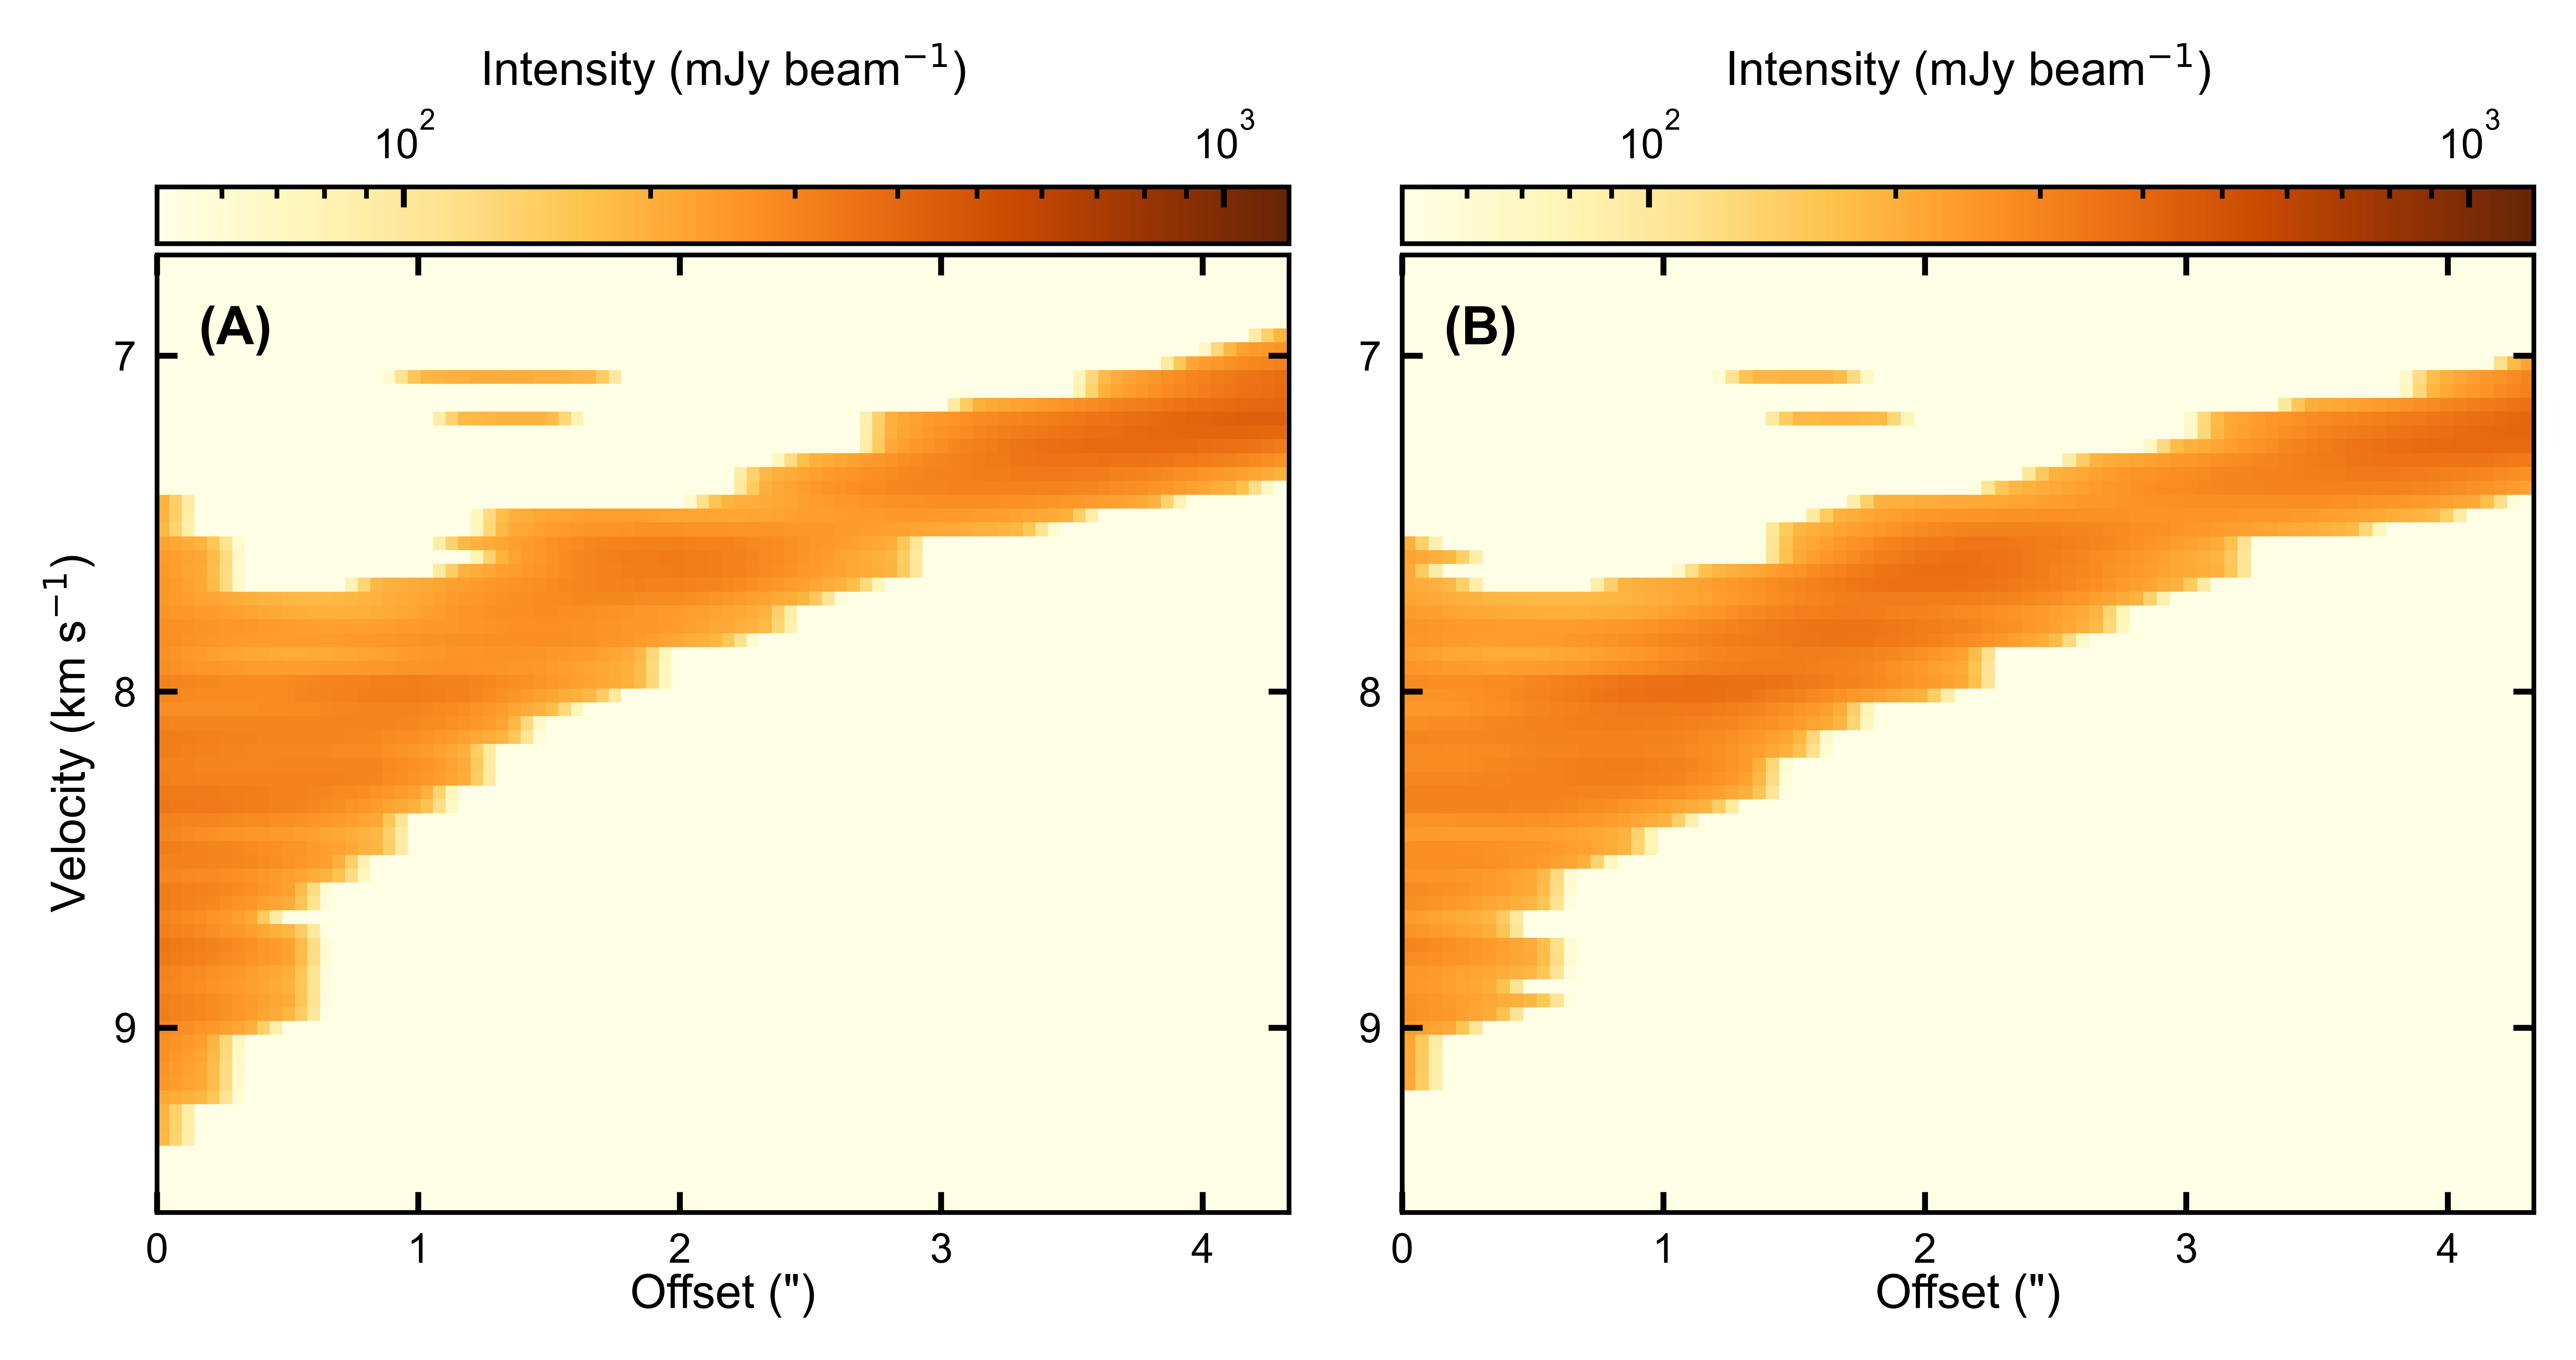

In [10]:
peak_intensities = np.nanmax(data_expanded, axis=1)  # Max along velocity (axis=1)
peak_velocity_indices = np.nanargmax(data_expanded.T, axis=1)  # Indices of peaks
peak_velocities = y_new_flipped[peak_velocity_indices]


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Myriad Pro', 'Arial', 'Helvetica', 'DejaVu Sans']

fig = plt.figure(figsize=(7.25, 3.5), dpi=1200)
plt.subplots_adjust(wspace=0.1)
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)


Norm = LogNorm(vmin=50, vmax=1200)
im = ax1.imshow(data_expanded, cmap='YlOrBr', aspect='auto', norm=Norm, origin='lower',
                extent=[x_new.min(), x_new.max(), y_new.max(), y_new.min()])

cb = fig.colorbar(im, ax=ax1, pad=0.01, shrink=1, location='top')
cb.set_label(r'Intensity (mJy beam$^{-1}$)', fontsize=8, labelpad=5) 

cb.ax.tick_params(labelsize=7, direction='in', length=3.5, width=1.3) 
cb.ax.minorticks_on()
cb.ax.tick_params(axis='x', which='minor', direction='in', length=2, width=0.8, color='k')
cb.ax.tick_params(axis='x', which='major', direction='in', length=3.5, width=1, color='k')

ax1.set_xlabel('Offset (")', fontsize=8, labelpad=0.5)
ax1.set_ylabel(r'Velocity (km s$^{-1}$)', fontsize=8, labelpad=3)
ax1.tick_params(axis='both', which='major', direction='in', labelsize=7, color='k', width=1, length=3.5, 
                top=True, bottom=True, left=True, right=True)
ax1.text(0.3, 6.85, '(A)', color='k', fontsize=9, ha='center', va='top', weight='bold')

ax1.set_xticks([0, 1, 2, 3, 4])
ax1.set_yticks([7.0, 8.0, 9.0])

ax1.set_xlim(0, 4.33)
ax1.set_ylim(9.55, 6.7)



im = ax2.imshow(data_expanded1, cmap='YlOrBr', aspect='auto', norm=Norm, origin='lower',
                extent=[x_new1.min(), x_new1.max(), y_new1.max(), y_new1.min()])

cb = fig.colorbar(im, ax=ax2, pad=0.01, shrink=1, location='top')
cb.set_label(r'Intensity (mJy beam$^{-1}$)', fontsize=8, labelpad=5)


cb.ax.tick_params(labelsize=7, direction='in', length=3.5, width=1.3)
cb.ax.minorticks_on()
cb.ax.tick_params(axis='x', which='minor', direction='in', length=2, width=0.8, color='k')
cb.ax.tick_params(axis='x', which='major', direction='in', length=3.5, width=1, color='k')

ax2.set_xlabel('Offset (")', fontsize=8, labelpad=0.5)
ax2.tick_params(axis='both', which='major', direction='in', labelsize=7, color='k', width=1, length=3.5, 
                top=True, bottom=True, left=True, right=True)

ax2.text(0.3, 6.85, '(B)', color='k', fontsize=9, ha='center', va='top', weight='bold')

ax2.set_xticks([0, 1, 2, 3, 4])
ax2.set_yticks([7.0, 8.0, 9.0])

ax2.set_xlim(0, 4.33)
ax2.set_ylim(9.55, 6.7)



fig.savefig('./HOPS-182_PV_SA.png', dpi=1200, bbox_inches='tight', pad_inches=0.1)